<a href="https://colab.research.google.com/github/nanduvarghese-glitch/gen-ai/blob/main/DAY7/Twitter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import kagglehub

path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [15]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/twitter-entity-sentiment-analysis/twitter_validation.csv
/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv


In [16]:
import pandas as pd

train_df = pd.read_csv(
    os.path.join(path, "twitter_training.csv")
)

val_df = pd.read_csv(
    os.path.join(path, "twitter_validation.csv")
)

print(train_df.head())
print(train_df.shape)

   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     
(74681, 4)


In [17]:
import pandas as pd
import os

train_file = os.path.join(path, "twitter_training.csv")

df_train = pd.read_csv(
    train_file,
    header=None,
    names=[
        "Tweet_ID",
        "Entity",
        "Sentiment",
        "Tweet"
    ]
)

df_train.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [18]:
df_train.to_csv(
    "/content/twitter_training.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!


In [19]:
df = pd.read_csv(
    "/content/twitter_training.csv"
)

print(df.head())
print(df.shape)


   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
(74682, 4)


In [20]:
import pandas as pd

df = pd.read_csv("/content/twitter_training.csv")

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [21]:
print(df.shape)

df.info()

df['Sentiment'].value_counts()

(74682, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


In [22]:
df = df.dropna()

print(df.shape)

(73996, 4)


In [23]:
from sklearn.model_selection import train_test_split

X = df['Tweet']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 59196
Testing samples: 14800


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(59196, 5000)


In [25]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [26]:
y_pred = model.predict(
    X_test_tfidf
)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.6494594594594595


In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

  Irrelevant       0.75      0.37      0.50      2575
    Negative       0.64      0.81      0.71      4472
     Neutral       0.67      0.55      0.61      3622
    Positive       0.62      0.74      0.68      4131

    accuracy                           0.65     14800
   macro avg       0.67      0.62      0.62     14800
weighted avg       0.66      0.65      0.64     14800



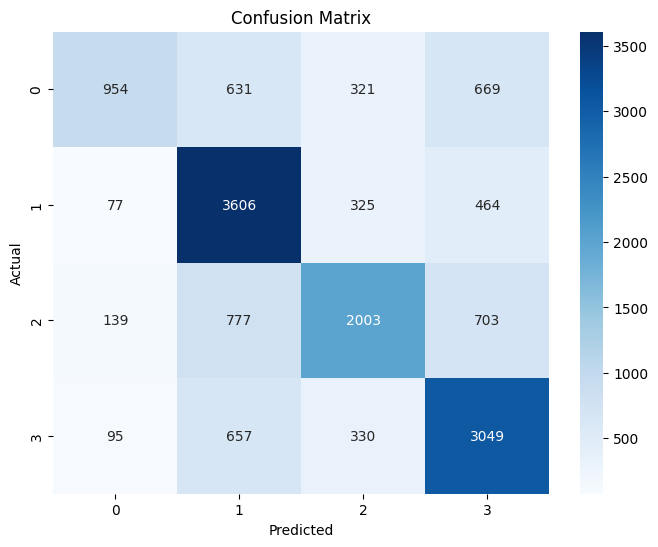

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
sample_tweet = [
    "This game is absolutely amazing"
]

sample_vector = tfidf.transform(
    sample_tweet
)

prediction = model.predict(
    sample_vector
)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

print(
    "LR Accuracy:",
    accuracy_score(y_test, lr_pred)
)

LR Accuracy: 0.6977027027027027


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

rf_pred = rf.predict(X_test_tfidf)

print(
    "RF Accuracy:",
    accuracy_score(y_test, rf_pred)
)

RF Accuracy: 0.8872297297297297


In [33]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, svm_pred)
)

SVM Accuracy: 0.7189189189189189
